<a href="https://colab.research.google.com/github/Tchalz/delete_now/blob/master/CREDIT_CARD_PROJECT_UNSUPERVISED_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##IMPORT LIBRARIES

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

##LOAD DATASET

In [38]:
df = pd.read_csv('/content/creditcard.csv')

In [39]:
df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [40]:
df.shape

(284807, 31)

##CHECK FOR MISSING VALUES AND DUPLICATES

In [41]:
df.duplicated().sum()

np.int64(1081)

In [42]:
df.drop_duplicates(inplace=True)

In [43]:
df.duplicated().sum()

np.int64(0)

In [59]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [44]:
df.duplicated().sum()

np.int64(0)

##FEATURE SELECTION

In [45]:
X = df.drop('Class', axis=1)

##KEEP Y ONLY FOR EVALUATION

In [46]:
y = df['Class']

##SCALE FEATURES

In [47]:
scaler = StandardScaler()

In [48]:
X_scaled = scaler.fit_transform(X)

##TRAIN ISOLATION FOREST
   Contamination = Expected Fraud %

In [49]:
model = IsolationForest(contamination=0.01, random_state=42, n_estimators=100)

In [50]:
model.fit(X_scaled)

IsolationForest(contamination=0.01, random_state=42)

In [62]:
model.predict(X_scaled)


array([1, 1, 1, ..., 1, 1, 1])

##predict Outliers

In [63]:
pred = model.predict(X_scaled)          # 7. Predict Outliers
                                          # Output:
                                          # 1 = normal
                                          # -1 = anomaly


##convert:   
Normal=0           

Fraud=1

In [64]:
pred = np.where(pred == -1, 1, 0)               #convert: normal=0, fraud=1

##COUNT FRAUD PREDICTIONS

In [53]:
print("Predicted fraud:", sum(pred))
print("Actual fraud:", sum(y))

Predicted fraud: 278050
Actual fraud: 473


##EVALUATE

In [55]:
# 8. Evaluate
print(confusion_matrix(y, pred))
print(classification_report(y, pred))

[[280665   2588]
 [   223    250]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    283253
           1       0.09      0.53      0.15       473

    accuracy                           0.99    283726
   macro avg       0.54      0.76      0.57    283726
weighted avg       1.00      0.99      0.99    283726



In [56]:
y.isna().sum()

np.int64(0)

##COUNT FRAUD PREDICTIONS AND ACTUAL FRAUD COUNT

In [57]:
print('predicted fraud cases:', sum(pred))
print('actual fraud cases:', sum(y))
print('accuracy:', sum(pred)/len(pred))

predicted fraud cases: 2838
actual fraud cases: 473
accuracy: 0.010002608150116662


##VISUALIZATION

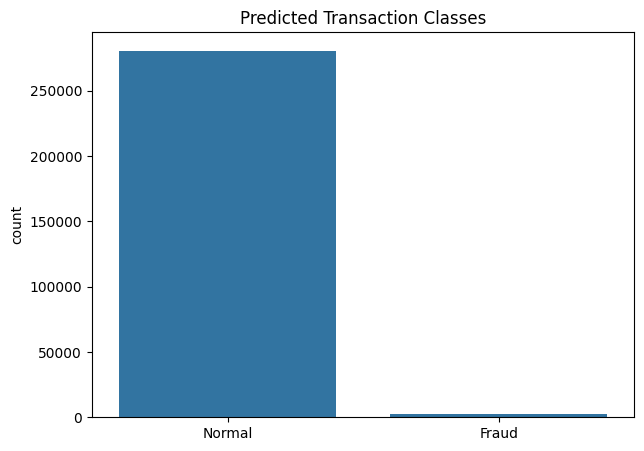

In [58]:
plt.figure(figsize=(7,5))
sns.countplot(x=pred)
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.title("Predicted Transaction Classes")
plt.show()

##FRAUD AMOUNT ANALYSIS

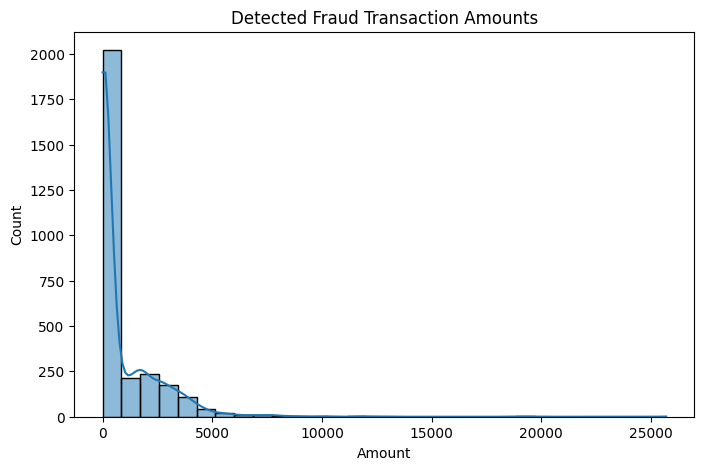

In [87]:
fraud_cases = df[pred == 1]

plt.figure(figsize=(8,5))
sns.histplot(fraud_cases["Amount"], bins=30, kde=True)
plt.title("Detected Fraud Transaction Amounts")
plt.show()